# Análisis de sentimientos - Clasificación de críticas de películas filmaffinity

* Notebook introductorio sobre clasificación de textos, aplicando algoritmos de aprendizaje sencillos.


* Este notebook tiene como objetivo mostrar todo el proceso de clasificación de textos (análisis de sentimientos) sobre críticas de películas.


* El proceso realizado es el siguiente:

1. Carga de datos
2. Definición del target en función de la nota de la crítica {Negativo, Neutro, Positivo}
3. Normalización de textos
4. Particionado de datos en entrenamiento y test
5. Creacción del modelos de bolsa de palabras y su apliación a los textos
6. Creacción de modelos de clasificación con algoritmos de aprendizaje sencillos de clasificación
7. Evaluación de los modelos


## 1.- Carga de datos

In [8]:
import pandas as pd

df = pd.read_table('/content/reviews_filmaffinity.csv', sep=r'\|\|', header=0, engine='python')
df.sample(5)

,film_name,gender,film_avg_rate,review_rate,review_title,review_text
4659,Planet 51,Animación,"5,8",5.0,El dinero fue a parar al espacio,Tiene como título honorífico ser la más cara d...
5107,Mientras dure la guerra,Drama,"6,8",6.0,PODRIA HABER SIDO MEJOR,Tenía ganas de verla porque me interesaba la h...
7792,AirBag,Comedia,"6,6",6.0,"Original en su día, hoy copiada hasta la sacie...",Estamos sin duda alguna ante una de las comedi...
3869,Celda 211,Thriller,"7,7",7.0,Brutal,"Espectacular, impactante, emocional. De lo mej..."
746,Lo imposible,Drama,"6,8",2.0,Ha sido posible,Sólo un plan de marketing digno de un estudio ...


Para cargar el archivo CSV, puedes subirlo directamente a tu sesión de Colab. Utiliza el siguiente código para abrir un cuadro de diálogo de selección de archivos. Una vez que hayas subido el archivo, se almacenará en el sistema de archivos temporal de Colab.

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving reviews_filmaffinity.csv to reviews_filmaffinity (1).csv
User uploaded file "reviews_filmaffinity (1).csv" with length 11536979 bytes


Ahora que el archivo está subido, puedes cargarlo en un DataFrame de pandas. **Asegúrate de que el nombre del archivo en `pd.read_table` coincida exactamente con el nombre del archivo que acabas de subir.** Además, he corregido el `SyntaxWarning` en el parámetro `sep` usando una cadena raw.

In [9]:
import pandas as pd

# Asume que el archivo subido se llama 'reviews_filmaffinity.csv'
# Si el nombre de tu archivo es diferente, actualiza la línea siguiente.
file_name = 'reviews_filmaffinity.csv'

df = pd.read_table(file_name, sep=r'\|\|', header=0, engine='python')
df.sample(5)

,film_name,gender,film_avg_rate,review_rate,review_title,review_text
3577,Alatriste,Aventuras,"5,5",9.0,LA MEJOR PELÍCULA ESPAÑOLA DE LA HISTORIA,Cuando aquellos que predican con la memoria hi...
7961,Las 13 rosas,Drama,"6,6",8.0,"Buena ambientación de época, históricamente pr...","Vi “Las 13 rosas” (España, 2007), dirigida po..."
1561,La gran aventura de Mortadelo y Filemón,Comedia,"4,8",3.0,"Pobrecillos, pobrecillos","Luego, nos preguntamos la causa del porque el ..."
2852,Campeones,Comedia,"6,9",6.0,Aceptarlos y reíros de ellos.,Muy esquemático:1. Tiene escenas muy graciosas...
8161,Los dos lados de la cama,Comedia,"5,5",5.0,hay cama para rato,No fui con demasiado entusiasmo a ver la conti...


## 2.- Distribución de votos (Positivo {>6} - Neutro {4-6} - Negativo {4>})

1.- Creamos una nueva columna con la polaridad del voto: Positivo \[10, 6), Neutro [6, 4], Negativo (4, 0\].

2.- Distribución numérica de los votos de las críticas.

3.- Distribución categórica de la polaridad de los votos.

4.- Distribución de los votos por película.

In [10]:
# 1.- Nueva columna con la polaridad de los votos
df['polaridad'] = df['review_rate'].apply(lambda  x: 'positivo' if x > 6
                                          else ('negativo' if x < 4
                                                else 'neutro'))
df.sample(5)

,film_name,gender,film_avg_rate,review_rate,review_title,review_text,polaridad
8594,La isla mínima,Cine negro,"7,2",10.0,Obra maestra,Me ha parecido una obra maestra de principio a...,positivo
4128,Celda 211,Thriller,"7,7",9.0,Un dia en prisión,Celda 211 es un relato violento e intenso que ...,positivo
1752,Ágora,Aventuras,"6,5",7.0,Crítica al fundamentalismo que no cala.,"La factura es impecable, los actores están tod...",positivo
297,Ocho apellidos vascos,Comedia,"6,0",4.0,Sobrevalorada,Una de dos: o yo no la he entendido o es que n...,neutro
7482,REC,Terror,"6,6",8.0,Una noche muy larga....,Nunca olvidaré la primera vez que ví esta pelí...,positivo


Text(30.764506172839504, 0.5, 'Nº Votos')

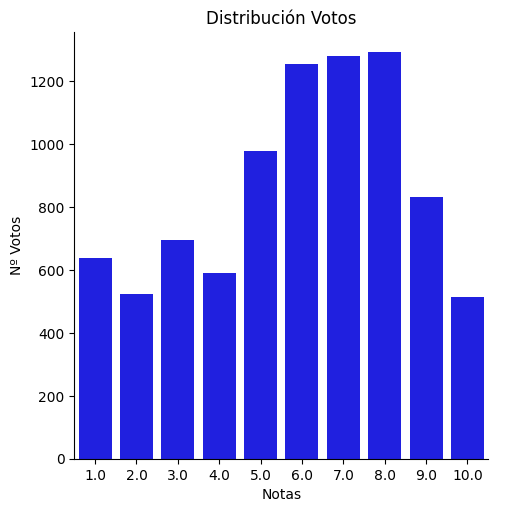

In [11]:
# 2.-  Distribución numérica de los votos de las críticas.

import matplotlib.pyplot as plt
import seaborn as sns


sns.catplot(x='review_rate', kind='count', color='b', data=df)
plt.title('Distribución Votos')
plt.xlabel('Notas')
plt.ylabel('Nº Votos')

Text(30.764506172839504, 0.5, 'Nº Votos')

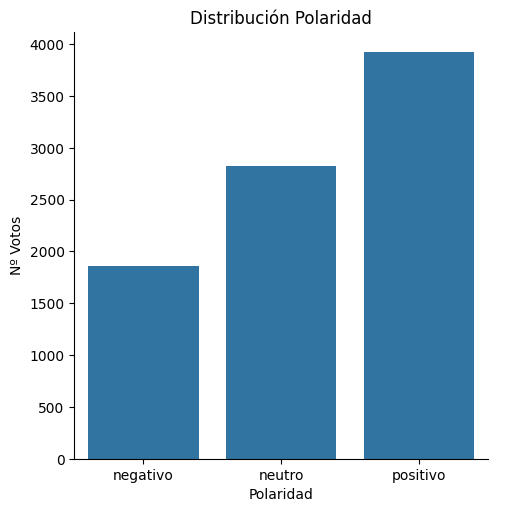

In [12]:
# 3.-  Distribución de votos por polaridad

sns.catplot(x='polaridad', kind='count', data=df,  order=['negativo', 'neutro', 'positivo'])
plt.title('Distribución Polaridad')
plt.xlabel('Polaridad')
plt.ylabel('Nº Votos')

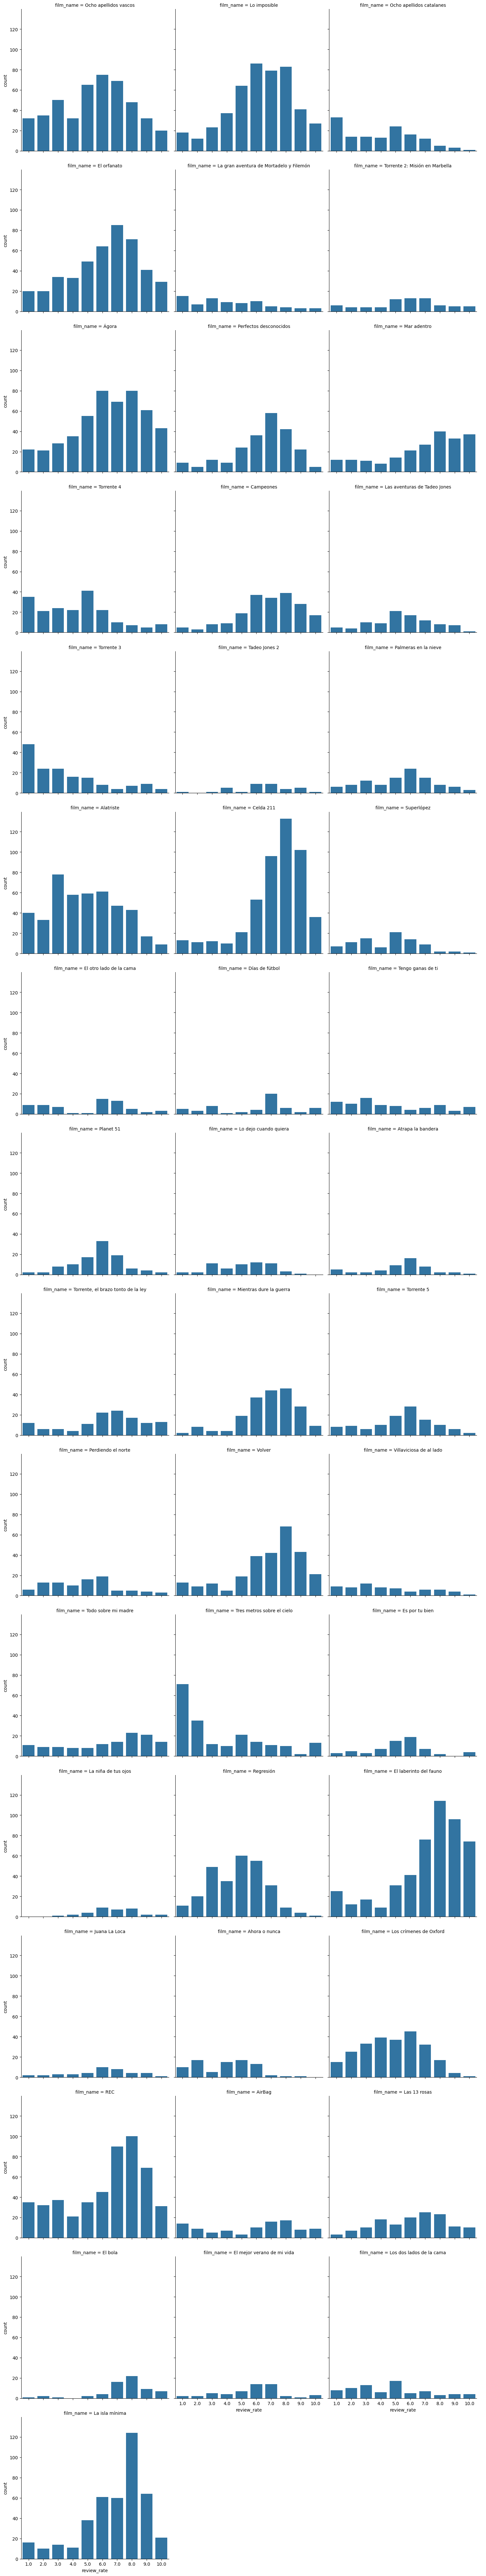

In [13]:
# 4.- Distribución de los votos por película.

sns.catplot(x="review_rate", col="film_name", data=df, kind='count', col_wrap=3)

## 3.- Normalización de textos

* Vamos a definir como texto a clasificar título y la crítica, ya que el título aporta significado al texto.


* En este punto realizaremos los siguientes pasos:

1. Concatenación de título y crítica
1. Pasamos a array de numpy el texto y el target (polaridad)
1. Importamos el modelo de spacy en español
1. Normalización de los textos: La normalización es una tarea que tiene como objetivo poner todo el texto en igualdad de condiciones; como por ejemplo:
        
    * Pasar todo el texto a minúsculas (o mayúsculas)
    * Eliminar signos de puntuación (puntos, comas, comillas, etc)
    * Quitar las stop-words: palábras que no aportan significado a los textos
    * Convertir números a su equivalente a palabras
    * Transformar la palabra a su lema
    * Pasar emoticonos a textos
    * etc.

In [14]:
# 1.- Concatenación de título y crítica

df['texto'] = df['review_title'] + ' ' + df['review_text']
df.head(5)

,film_name,gender,film_avg_rate,review_rate,review_title,review_text,polaridad,texto
0,Ocho apellidos vascos,Comedia,"6,0",3.0,OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO,La mayor virtud de esta película es su existen...,negativo,OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO...
1,Ocho apellidos vascos,Comedia,"6,0",2.0,El perro verde,"No soy un experto cinéfilo, pero pocas veces m...",negativo,"El perro verde No soy un experto cinéfilo, per..."
2,Ocho apellidos vascos,Comedia,"6,0",2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...,negativo,Si no eres de comer mierda... no te comas esta...
3,Ocho apellidos vascos,Comedia,"6,0",2.0,Aida: The movie,"No sé qué está pasando, si la gente se deja ll...",negativo,"Aida: The movie No sé qué está pasando, si la ..."
4,Ocho apellidos vascos,Comedia,"6,0",2.0,UN HOMBRE SOLO (Julio Iglesias 1987),"""Pero cuando amanece,y me quedo solo,siento en...",negativo,"UN HOMBRE SOLO (Julio Iglesias 1987) ""Pero cua..."


In [15]:
# 2.- Pasamos a array de numpy el texto (X) y el target-polaridad (y)

X = df['texto'].values
y =  df['polaridad'].values


In [16]:
# 3.- Importamos el modelo de spacy en español

import spacy

# Este comando se ejecuta en consola
!python -m spacy download es

⚠ As of spaCy v3.0, shortcuts like 'es' are deprecated. Please use the
full pipeline package name 'es_core_news_sm' instead.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 71.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**NOTA:** *Si ejecutais este notebook en local, es posible que os de un error a la hora de importar el modelo de NLP en español. Si da ese error debéis de cambiar el nombre del modelo de 'es' a 'es_core_news_sm' o como se indique en el proceso de importación del modelo de Spacy.*

In [18]:
import re

from tqdm import tqdm

# Importamos el modelo en español de spacy
nlp = spacy.load('es_core_news_sm')


def normalize(corpus):
    """Función que dada una lista de textos, devuelve esa misma lista de textos
       con los textos normalizados, realizando las siguientes tareas:
       1.- Pasamos la palabra a minúsculas
       2.- Elimina signos de puntuación
       3.- Elimina las palabras con menos de 3 caracteres (palabras que seguramente no aporten significado)
       4.- Elimina las palabras con más de 11 caracteres (palabras "raras" que seguramente no aporten significado)
       5.- Elimina las stop words (palabras que no aportan significado como preposiciones, determinantes, etc.)
       6.- Elimina los saltos de línea (en caso de haberlos)
       7.- Eliminamos todas las palabras que no sean Nombres, adjetivos, verbos o advervios
    """
    for index, doc in enumerate(tqdm(corpus)):
        doc = nlp(doc.lower())
        corpus[index] = " ".join([word.lemma_ for word in doc if (not word.is_punct)
                                  and (len(word.text) > 3)
                                  and (len(word.text) < 11)
                                  and (not word.is_stop)
                                  and re.sub(r'\s+', ' ', word.text)
                                  and (word.pos_ in ['NOUN', 'ADJ', 'VERB', 'ADV'])])


    return corpus

# Normalización
X_norm = normalize(X)

100%|██████████| 8603/8603 [05:38<00:00, 25.43it/s]


## 4.- Bolsa de Palabras (BoW) - Particionado de datos

In [19]:
# 1.- Particionamos los textos en entrenamiento y test (80% entrenamiento, 20% test)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=0)

print('Textos de entrenamiento: {}'.format(len(X_train)))
print('Textos de test: {}'.format(len(X_test)))

Textos de entrenamiento: 6882
Textos de test: 1721


* Mostramos la distribución del target de los datos de entrenamiento y test para ver si siguen una distribución similar.

[]

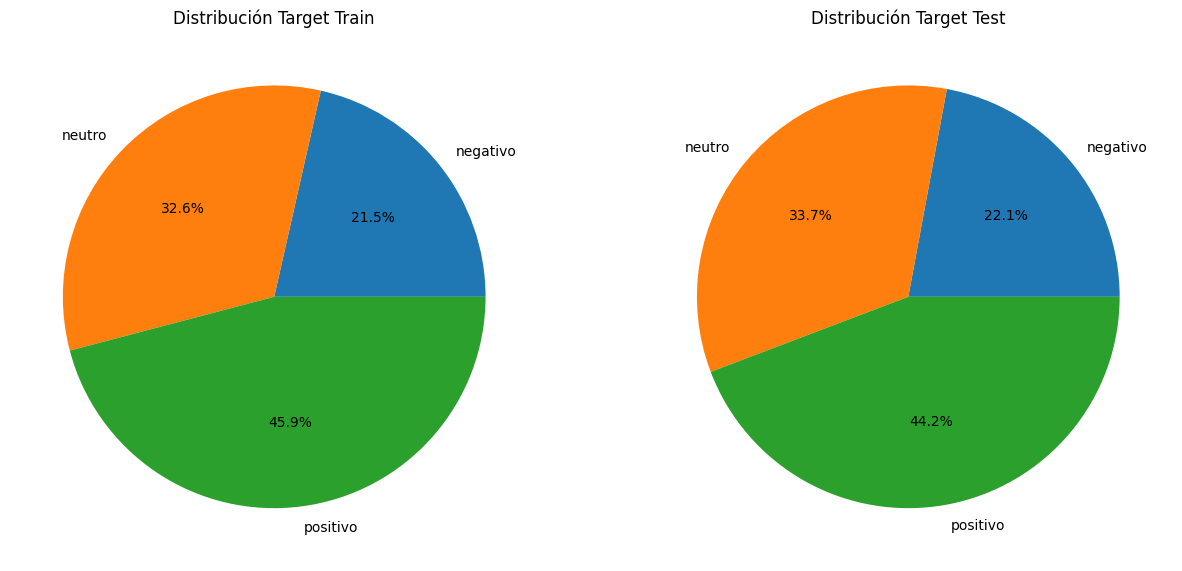

In [20]:
import numpy as np

keys_train, counts_train = np.unique(y_train, return_counts=True)
keys_test, counts_test = np.unique(y_test, return_counts=True)
perct_train = counts_train / np.sum(counts_train)
perct_test = counts_test / np.sum(counts_test)

plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
plt.pie(perct_train, labels=keys_train, autopct='%1.1f%%')
plt.title('Distribución Target Train')
plt.subplot(1, 2, 2)
plt.pie(perct_test, labels=keys_test, autopct='%1.1f%%')
plt.title('Distribución Target Test')
plt.plot()


### Creamos una bolsa de palabras de frecuencias con los textos de entrenamiento.

* Creamos un modelo de bolsa de palabras con las 2000 palabras más frecuentes de los textos de entrenamiento que aparezcan por lo menos en 3 documentos distintos.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=2000, min_df=3)

# Creamos el modelo de bolsa de palabras con los textos de entrenamiento y aplicamos el modelo
X_bow_train = bow.fit_transform(X_train)

# A modo de ejemplo mostramos las 20 primeras palabras de la bolsa de palabras
bow.get_feature_names_out()[0:21]

array(['2004', '2009', '2014', 'abajo', 'abandonar', 'abarcar', 'abierto',
       'abordar', 'abrir', 'absoluto', 'absurdo', 'abuela', 'aburrido',
       'aburrir', 'abusar', 'abuso', 'acabar', 'acaso', 'accidente',
       'acción', 'acento'], dtype=object)

* Con el modelo de bolsa de palabras creado con los textos de entrenamiento, aplicamos el modelo a los textos de test.

In [23]:
X_bow_test = bow.transform(X_test)

## 5.- Creacción de modelos (clasificación)

Utilizamos los siguientes algoritmos (o metaalgoritmos) de aprendizaje de clasificación para crear modelos predictivos capaces de clasificar una crítica de pelicula en alguna de las siguientes clases: {Negativa, Neutra, Positiva}

* Multinomial Naive Bayes
* Bernoulli Naive Bayes
* Regresion Logistica
* Support Vector Machine
* Random Forest (ensemble)

In [24]:

from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

mnb = MultinomialNB()
bnb = BernoulliNB()
lr = LogisticRegression(solver='lbfgs', multi_class='multinomial', max_iter=1000)
svm_lin = SVC(kernel='linear')
svm_rbf = SVC(kernel='rbf')
rf_20 = RandomForestClassifier(n_estimators=500, bootstrap=True, criterion='gini', max_depth=20, random_state=0)
rf_50 = RandomForestClassifier(n_estimators=500, bootstrap=True, criterion='gini', max_depth=50, random_state=0)

clasificadores = {'Multinomial NB': mnb,
                  'Bernoulli NB': bnb,
                  'Regresion Logistica': lr,
                  'SVM lineal': svm_lin,
                  'SVM Kernel rbf': svm_rbf,
                  'Random Forest d_20': rf_20,
                  'Random Forest d_50': rf_50}


# Ajustamos los modelos y calculamos el accuracy para los datos de entrenamiento
for k, v in clasificadores.items():
    print ('CREANDO MODELO: {clas}'.format(clas=k))
    v.fit(X_bow_train, y_train)

CREANDO MODELO: Multinomial NB
CREANDO MODELO: Bernoulli NB
CREANDO MODELO: Regresion Logistica


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


CREANDO MODELO: SVM lineal
CREANDO MODELO: SVM Kernel rbf
CREANDO MODELO: Random Forest d_20
CREANDO MODELO: Random Forest d_50


## 6.- Evaluación de los modelos

* Para cada uno de los modelos vamos a calcular las siguientes métricas de evaluación:

1. Accuracy
1. Precision
1. Recall
1. F1

In [25]:

from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score

def evaluation(model, name, X_train, y_train, X_test, y_test):
    """
    Función de devuelve en un diccionario las métricas de evaluación de
    Accuracy, Precision, Recall y F1 para los conjuntos de datos de entrenamiento y test
        model: modelo a evaluar
        name: nombre del modelo
        X_train: Variables de entrada del conjunto de datos de entrenamiento
        y_train: Variable de salida del conjunto de datos de entrenamiento
        X_test: Variables de entrada del conjunto de datos de test
        y_test: Variable de salida del conjunto de datos de test
        return: diccionario con el nombre del modelo y el valor de las métricas
    """
    model_dict = {}
    model_dict['name'] = name
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    model_dict['accuracy_train'] = accuracy_score(y_true=y_train, y_pred=y_pred_train)
    model_dict['accuracy_tests'] = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    model_dict['precision_train'] = precision_score(y_true=y_train, y_pred=y_pred_train, average='weighted')
    model_dict['precision_tests'] = precision_score(y_true=y_test, y_pred=y_pred_test, average='weighted')
    model_dict['recall_train'] = recall_score(y_true=y_train, y_pred=y_pred_train, average='weighted')
    model_dict['recall_tests'] = recall_score(y_true=y_test, y_pred=y_pred_test, average='weighted')
    model_dict['f1_train'] = f1_score(y_true=y_train, y_pred=y_pred_train, average='weighted')
    model_dict['f1_tests'] = f1_score(y_true=y_test, y_pred=y_pred_test, average='weighted')

    return model_dict


# Calculamos las métricas de los modelos por separado
evaluacion = list()
for key, model in clasificadores.items():
    evaluacion.append(evaluation(model=model, name=key,
                                 X_train=X_bow_train, y_train=y_train,
                                 X_test=X_bow_test, y_test=y_test))

# Pasamos los resultados a un DataFrame para visualizarlos mejor
df = pd.DataFrame.from_dict(evaluacion)
df.set_index("name", inplace=True)
df

,accuracy_train,accuracy_tests,precision_train,precision_tests,recall_train,recall_tests,f1_train,f1_tests
name,,,,,,,,
Multinomial NB,0.702557,0.617083,0.705998,0.617311,0.702557,0.617083,0.702053,0.614692
Bernoulli NB,0.648358,0.569436,0.687529,0.599546,0.648358,0.569436,0.651251,0.569843
Regresion Logistica,0.901482,0.602557,0.901145,0.599583,0.901482,0.602557,0.901083,0.600850
SVM lineal,0.937082,0.568274,0.937191,0.571613,0.937082,0.568274,0.936752,0.568920
SVM Kernel rbf,0.878669,0.637420,0.880627,0.635966,0.878669,0.637420,0.877049,0.625714
Random Forest d_20,0.786981,0.550261,0.847435,0.581653,0.786981,0.550261,0.779960,0.485123
Random Forest d_50,0.974426,0.614178,0.975756,0.617785,0.974426,0.614178,0.974422,0.586264


* Representamos las métricas para los diferentes modelos en un gráfico de barras:

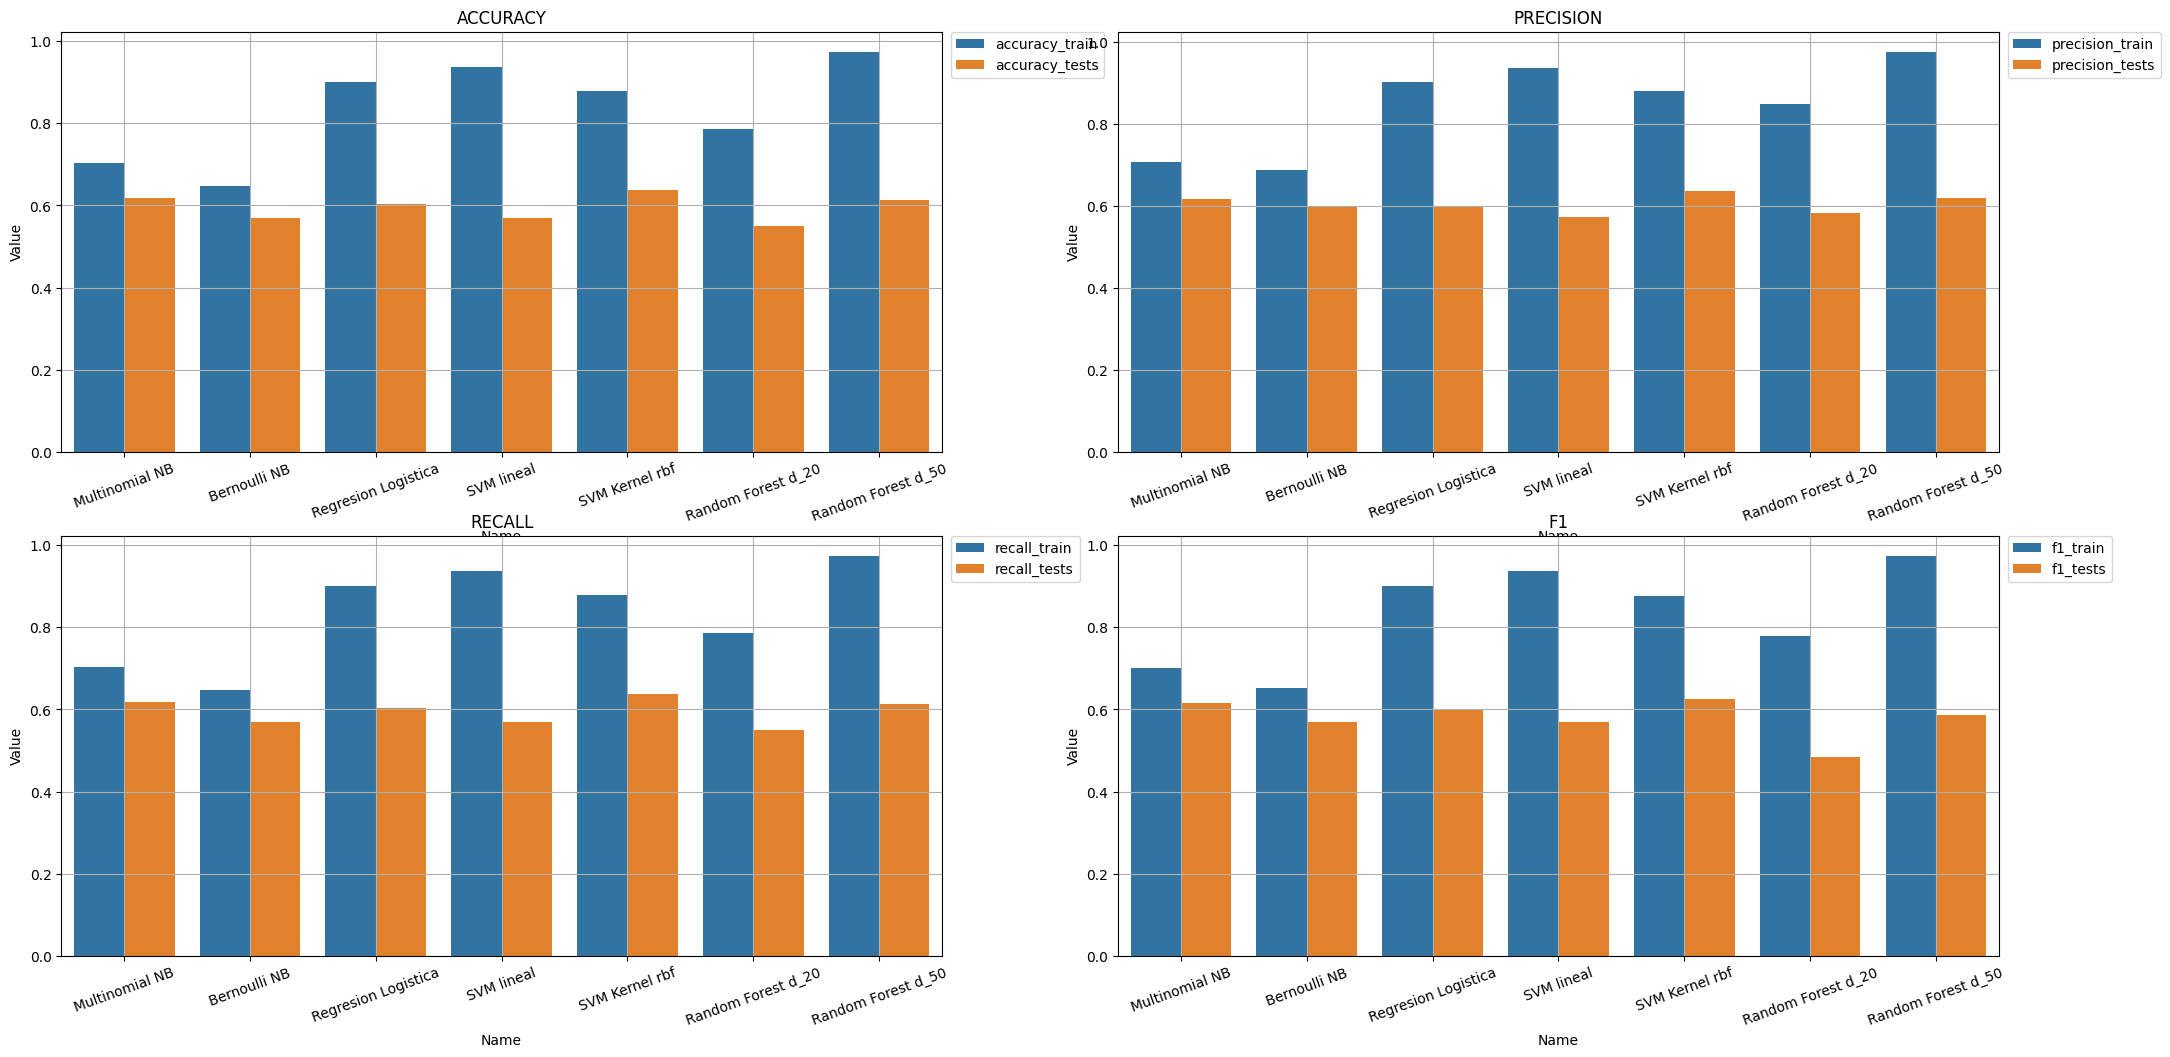

In [26]:
# Métricas a pintar
METRICS = ["accuracy", "precision", "recall", "f1"]

# Transformamos el dataframe para pintar las gráficas con seaborn
df_plot = df.reset_index().melt(id_vars='name').rename(columns=str.title)

plt.figure(figsize=(25, 12))
pos = 1
for metric in METRICS:
    # Filtramos la métrica a pintar
    df_aux = df_plot[df_plot['Variable'].str.contains(metric)]

    # Pintamos la gráfica en su posición 2x2
    plt.subplot(2, 2, pos)
    sns.barplot(x='Name', y='Value', hue='Variable', data=df_aux)
    plt.title(metric.upper())
    plt.grid()
    plt.legend(bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)
    plt.xticks(rotation=20)
    pos += 1
plt.show()

* Dibujamos las matrices de confusión de cada uno de los modelos creados para los textos de entrenamiento y test

Obteniendo Matriz de Confusión de: Multinomial NB
Obteniendo Matriz de Confusión de: Bernoulli NB
Obteniendo Matriz de Confusión de: Regresion Logistica
Obteniendo Matriz de Confusión de: SVM lineal
Obteniendo Matriz de Confusión de: SVM Kernel rbf
Obteniendo Matriz de Confusión de: Random Forest d_20
Obteniendo Matriz de Confusión de: Random Forest d_50


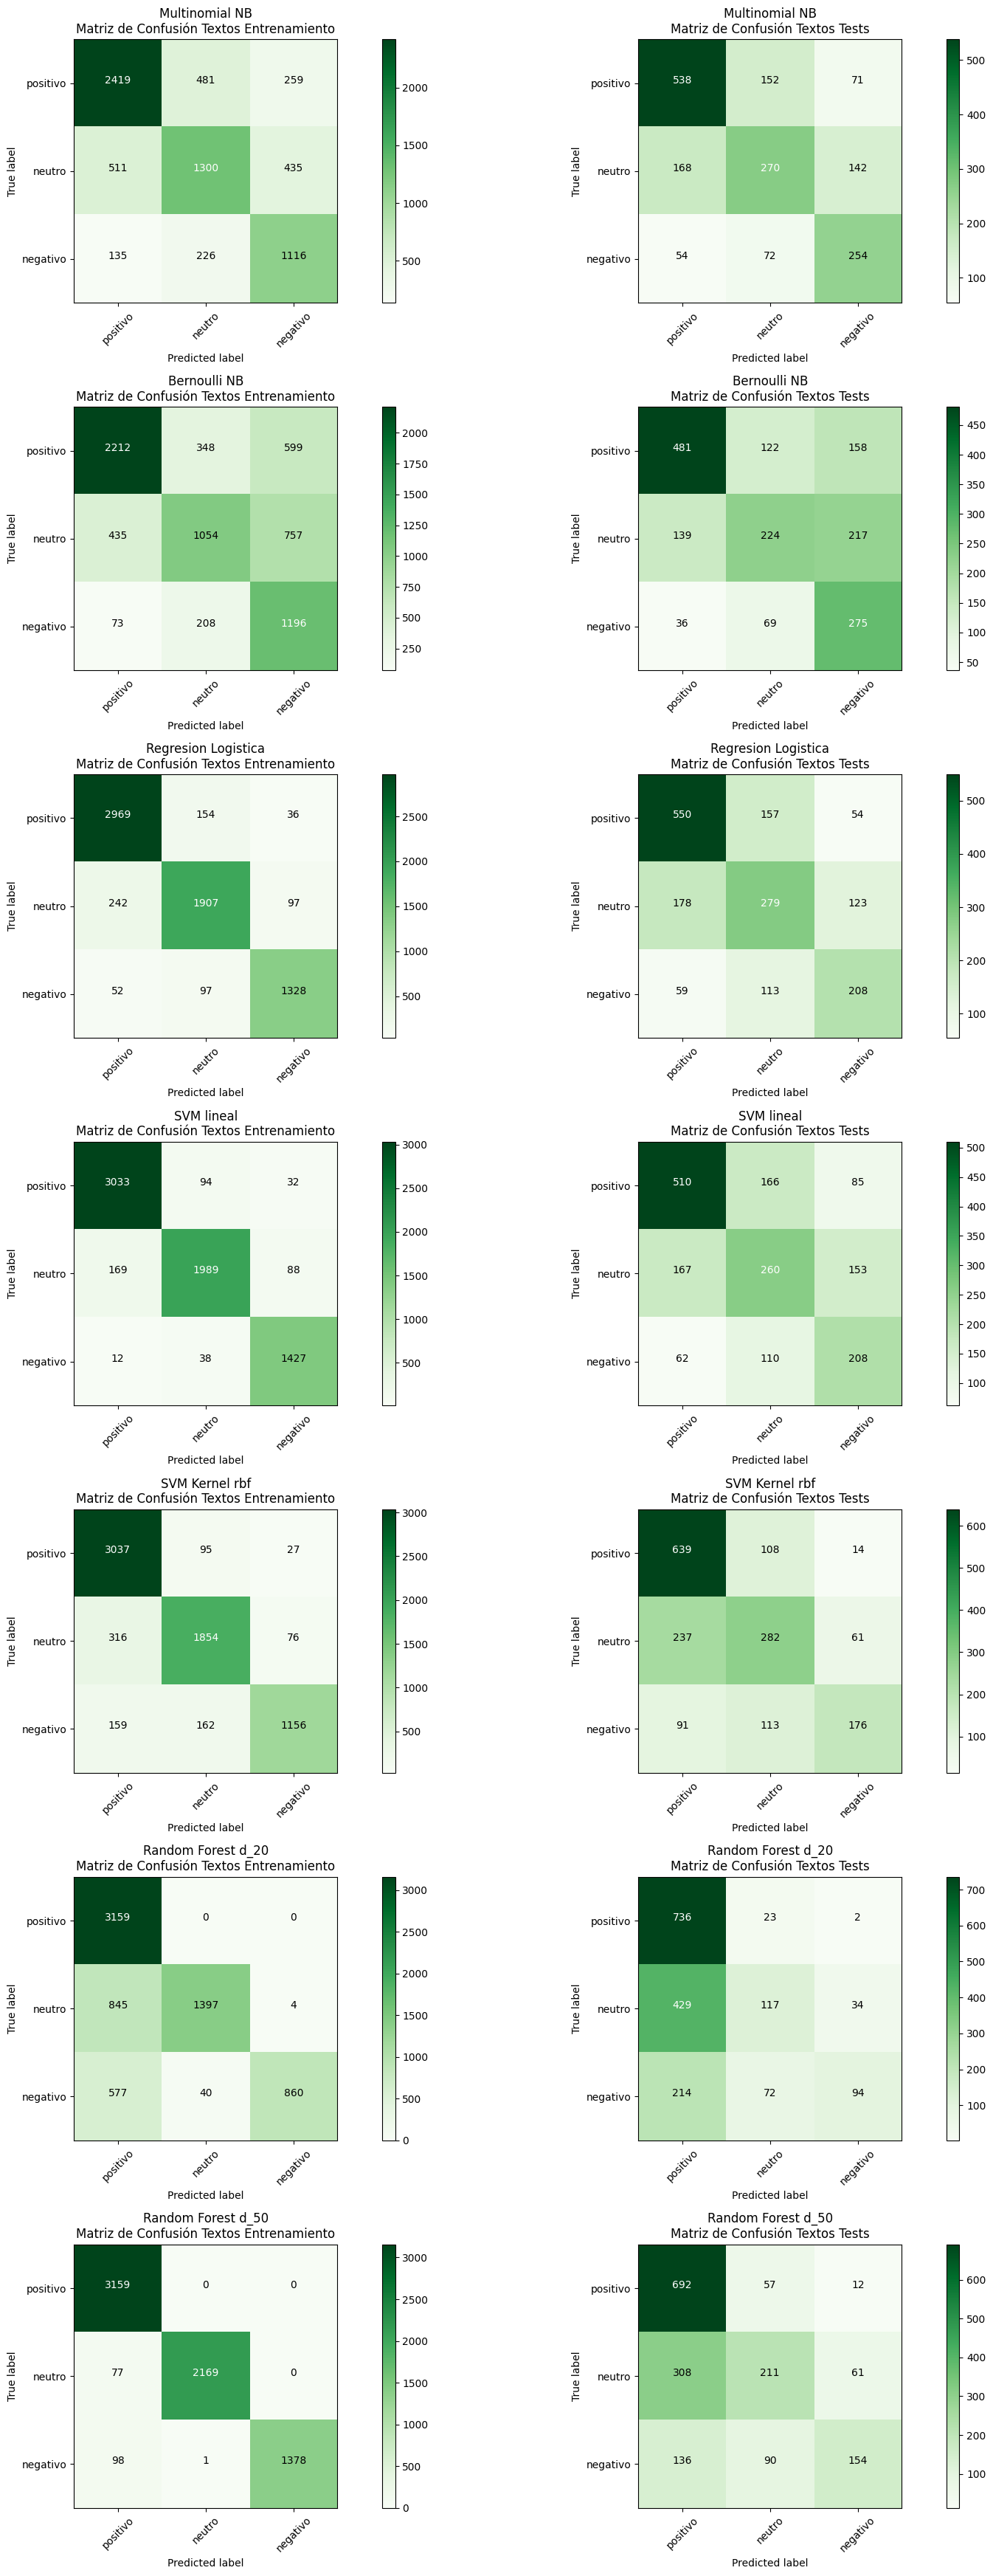

In [27]:
import itertools

from sklearn.metrics import confusion_matrix

polaridad = ['positivo', 'neutro', 'negativo']

# Obtenemos las Matrices de confusión
msc = list()
for k, v in clasificadores.items():
    print ('Obteniendo Matriz de Confusión de: {model}'.format(model=k))
    model = {}
    model['name'] = k
    y_pred_train = v.predict(X_bow_train)
    y_pred_test = v.predict(X_bow_test)
    model['confusion_matrix_train'] = confusion_matrix(y_true=y_train, y_pred=y_pred_train, labels=polaridad)
    model['confusion_matrix_test'] = confusion_matrix(y_true=y_test, y_pred=y_pred_test, labels=polaridad)
    msc.append(model)


# Definimos el heatmap de la matriz de confusión
def plot_confusion_matrix(cm, classes, title, cmap=plt.cm.Greens):
    """
    This function prints and plots the confusion matrix.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


# Pintamos las matrices de confusión
plt.figure(figsize=(20, 35))
pos = 0
for mc in msc:
    pos += 1
    plt.subplot(len(msc), 2, pos)
    plot_confusion_matrix(mc['confusion_matrix_train'], classes=polaridad,
                          title='{}\nMatriz de Confusión Textos Entrenamiento'.format(mc['name']))
    pos += 1
    plt.subplot(len(msc), 2, pos)
    plot_confusion_matrix(mc['confusion_matrix_test'], classes=polaridad,
                          title='{}\nMatriz de Confusión Textos Tests'.format(mc['name'] ))
plt.show()